In [1]:
from pathlib import Path
import os
import shutil

REPO_URL = "https://github.com/Tanvir-kabir-Rahib/VisDrone_Dataset.git"  # change if you fork/rename the repo
PROJECT_ROOT = Path("/content/VisDrone_Dataset")

if not (PROJECT_ROOT / "scripts" / "train_yolo.py").exists():
    assert REPO_URL.startswith("https://github.com/"), "Set REPO_URL to your GitHub repository first."
    if PROJECT_ROOT.exists():
        shutil.rmtree(PROJECT_ROOT)
    !git clone "$REPO_URL" "$PROJECT_ROOT"

os.chdir(PROJECT_ROOT)
print("Project root:", Path.cwd())

Cloning into '/content/VisDrone_Dataset'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 54 (delta 4), reused 54 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 10.45 MiB | 30.31 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Project root: /content/VisDrone_Dataset


In [2]:
!pip -q install -r requirements.txt kaggle

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No GPU found. In Colab, use Runtime > Change runtime type > T4 GPU.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:00
CUDA available: True
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount("/content/drive")
OUTPUT_ROOT = Path("/content/drive/MyDrive/visdrone_outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT_STR = str(OUTPUT_ROOT)
print("Output root:", OUTPUT_ROOT)

Mounted at /content/drive
Output root: /content/drive/MyDrive/visdrone_outputs


In [4]:
from google.colab import files

kaggle_json = Path("/root/.kaggle/kaggle.json")
if not kaggle_json.exists():
    print("Upload kaggle.json now.")
    uploaded = files.upload()
    if "kaggle.json" not in uploaded:
        raise FileNotFoundError("kaggle.json was not uploaded.")
    kaggle_json.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy("kaggle.json", kaggle_json)
    kaggle_json.chmod(0o600)

DATA_DOWNLOAD_ROOT = Path("/content/data")
DATA_DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)

if not list(DATA_DOWNLOAD_ROOT.rglob("VisDrone2019-DET-train")):
    !kaggle datasets download -d banuprasadb/visdrone-dataset -p /content/data --unzip

train_dirs = list(DATA_DOWNLOAD_ROOT.rglob("VisDrone2019-DET-train"))
assert train_dirs, "Could not find VisDrone2019-DET-train after download."
DATASET_ROOT = train_dirs[0].parent
DATASET_ROOT_STR = str(DATASET_ROOT)
print("Dataset root:", DATASET_ROOT)

Upload kaggle.json now.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/banuprasadb/visdrone-dataset
License(s): GNU Affero General Public License 3.0
100% 2.10G/2.10G [00:13<00:00, 171MB/s]

Dataset root: /content/data/VisDrone_Dataset


In [5]:
!python scripts/train_yolo.py --dataset-root "$DATASET_ROOT_STR" --dry-run
!python scripts/analyze_dataset.py --dataset-root "$DATASET_ROOT_STR" --output-dir "$OUTPUT_ROOT_STR/dataset" --sample-limit 6 --size-sample-limit 500

Dataset OK.
Resolved data YAML: outputs/training/visdrone_resolved.yaml
Training command: python scripts/train_yolo.py --model yolo11n.pt --epochs 50 --imgsz 960 --batch 8
Classes of interest for the assessment: pedestrian + people = human, car = car.
Wrote /content/drive/MyDrive/visdrone_outputs/dataset/dataset_summary.json
Wrote visualizations to /content/drive/MyDrive/visdrone_outputs/dataset


In [6]:
RUN_SMOKE_TEST = False

if RUN_SMOKE_TEST:
    !python scripts/train_yolo.py \
      --dataset-root "$DATASET_ROOT_STR" \
      --model yolo11n.pt \
      --epochs 1 \
      --imgsz 640 \
      --batch 8 \
      --device 0 \
      --workers 8 \
      --project "$OUTPUT_ROOT_STR/training" \
      --name smoke-test

In [7]:
MODEL = "yolo11n.pt"
EPOCHS = 50
IMGSZ = 640
BATCH = 16
WORKERS = 8
CACHE = "disk"
FREEZE = 10
RUN_NAME = f"visdrone-{MODEL.replace('.pt', '')}-{IMGSZ}"

!python scripts/train_yolo.py \
  --dataset-root "$DATASET_ROOT_STR" \
  --model "$MODEL" \
  --epochs "$EPOCHS" \
  --imgsz "$IMGSZ" \
  --batch "$BATCH" \
  --device 0 \
  --workers "$WORKERS" \
  --cache "$CACHE" \
  --freeze "$FREEZE" \
  --project "$OUTPUT_ROOT_STR/training" \
  --name "$RUN_NAME"

usage: train_yolo.py [-h] [--dataset-root DATASET_ROOT] [--model MODEL]
                     [--epochs EPOCHS] [--imgsz IMGSZ] [--batch BATCH]
                     [--device DEVICE] [--project PROJECT] [--name NAME]
                     [--dry-run]
train_yolo.py: error: unrecognized arguments: --workers 8 --cache disk --freeze 10


In [8]:
best_weights = sorted((OUTPUT_ROOT / "training").rglob("best.pt"), key=lambda p: p.stat().st_mtime)[-1]
BEST_WEIGHTS = str(best_weights)
print("Best weights:", BEST_WEIGHTS)

Best weights: /content/drive/MyDrive/visdrone_outputs/training/visdrone-yolo11s-960/weights/best.pt


In [9]:
!python scripts/evaluate_yolo.py \
  --dataset-root "$DATASET_ROOT_STR" \
  --weights "$BEST_WEIGHTS" \
  --split val \
  --imgsz "$IMGSZ"

Traceback (most recent call last):
  File "/content/VisDrone_Dataset/scripts/evaluate_yolo.py", line 13, in <module>
    from scripts.train_yolo import validate_dataset, write_resolved_yaml
ModuleNotFoundError: No module named 'scripts'


In [10]:
!python scripts/detect_count.py \
  --dataset-root "$DATASET_ROOT_STR" \
  --weights "$BEST_WEIGHTS" \
  --split val \
  --limit 12 \
  --output-dir "$OUTPUT_ROOT_STR/predictions"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Processed 12 images into /content/drive/MyDrive/visdrone_outputs/predictions


0000001_02999_d_0000005_count.jpg


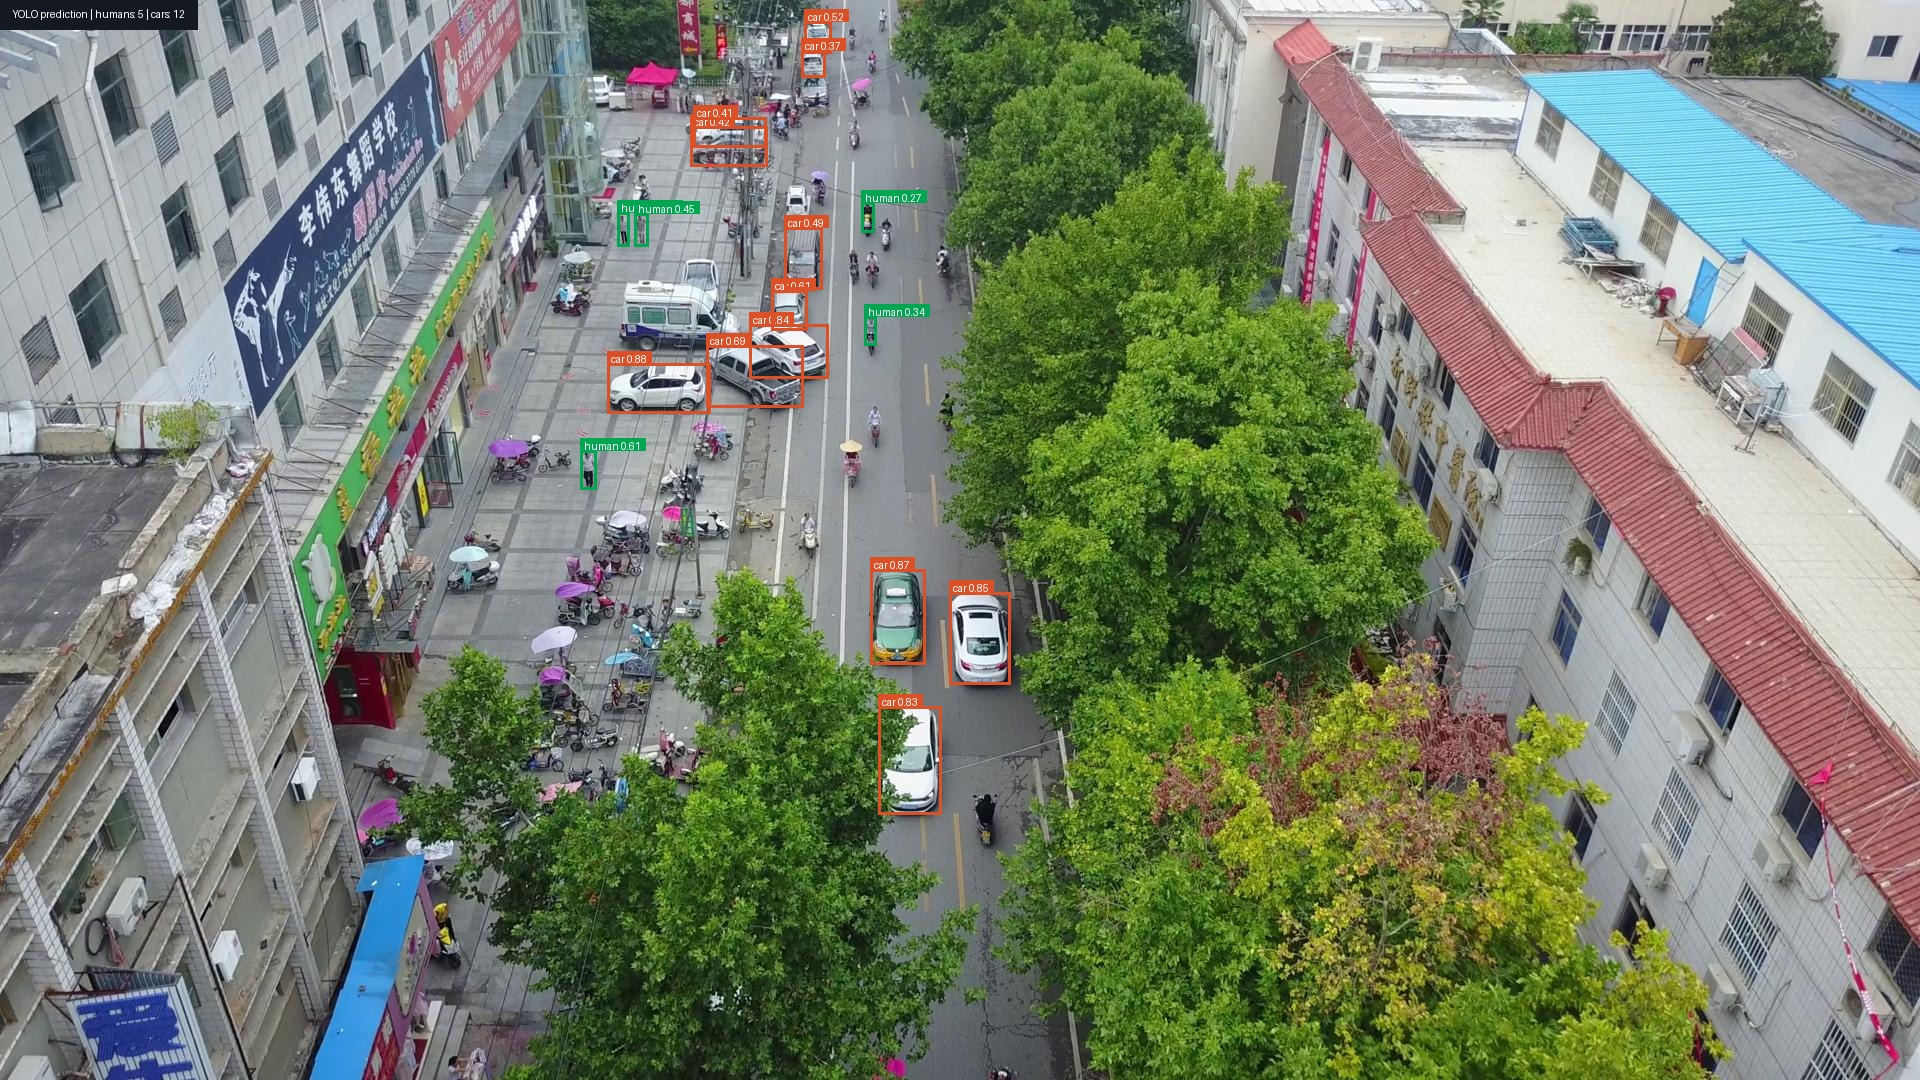

0000001_03499_d_0000006_count.jpg


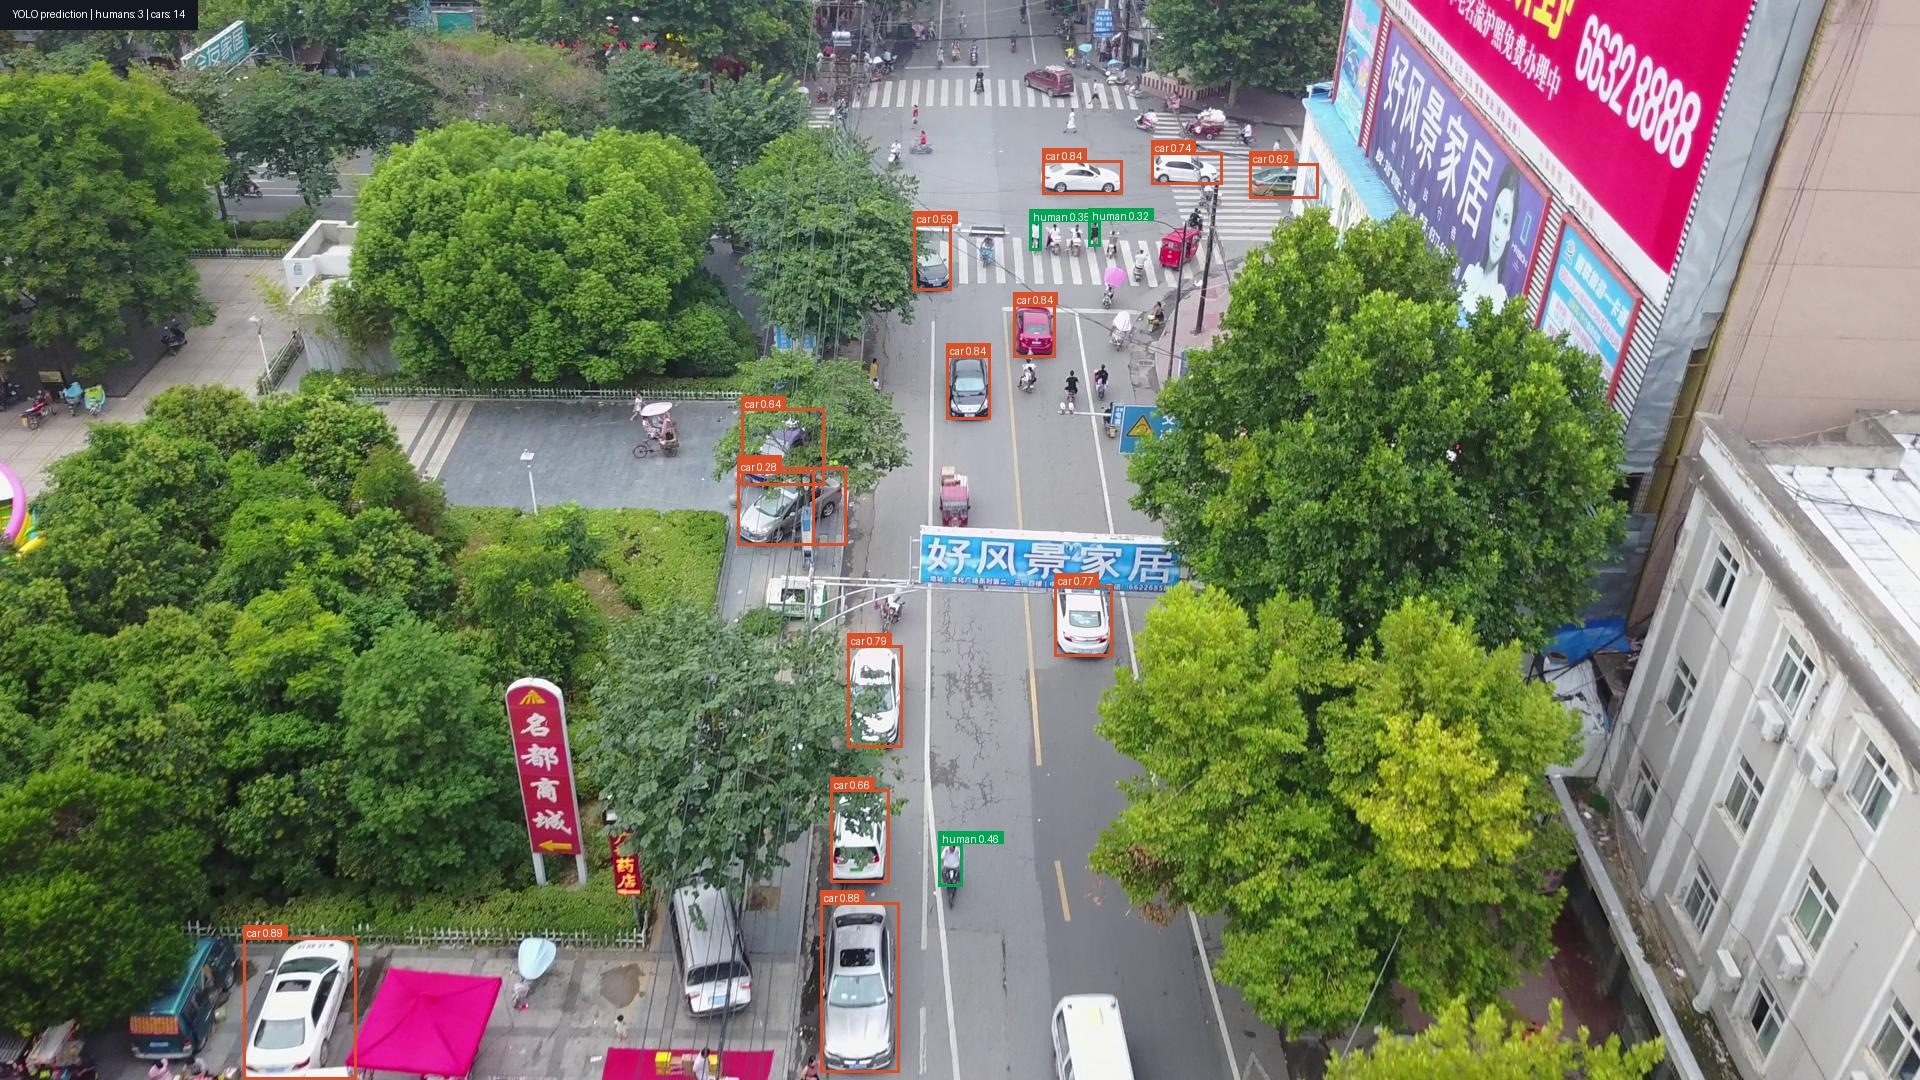

0000001_03999_d_0000007_count.jpg


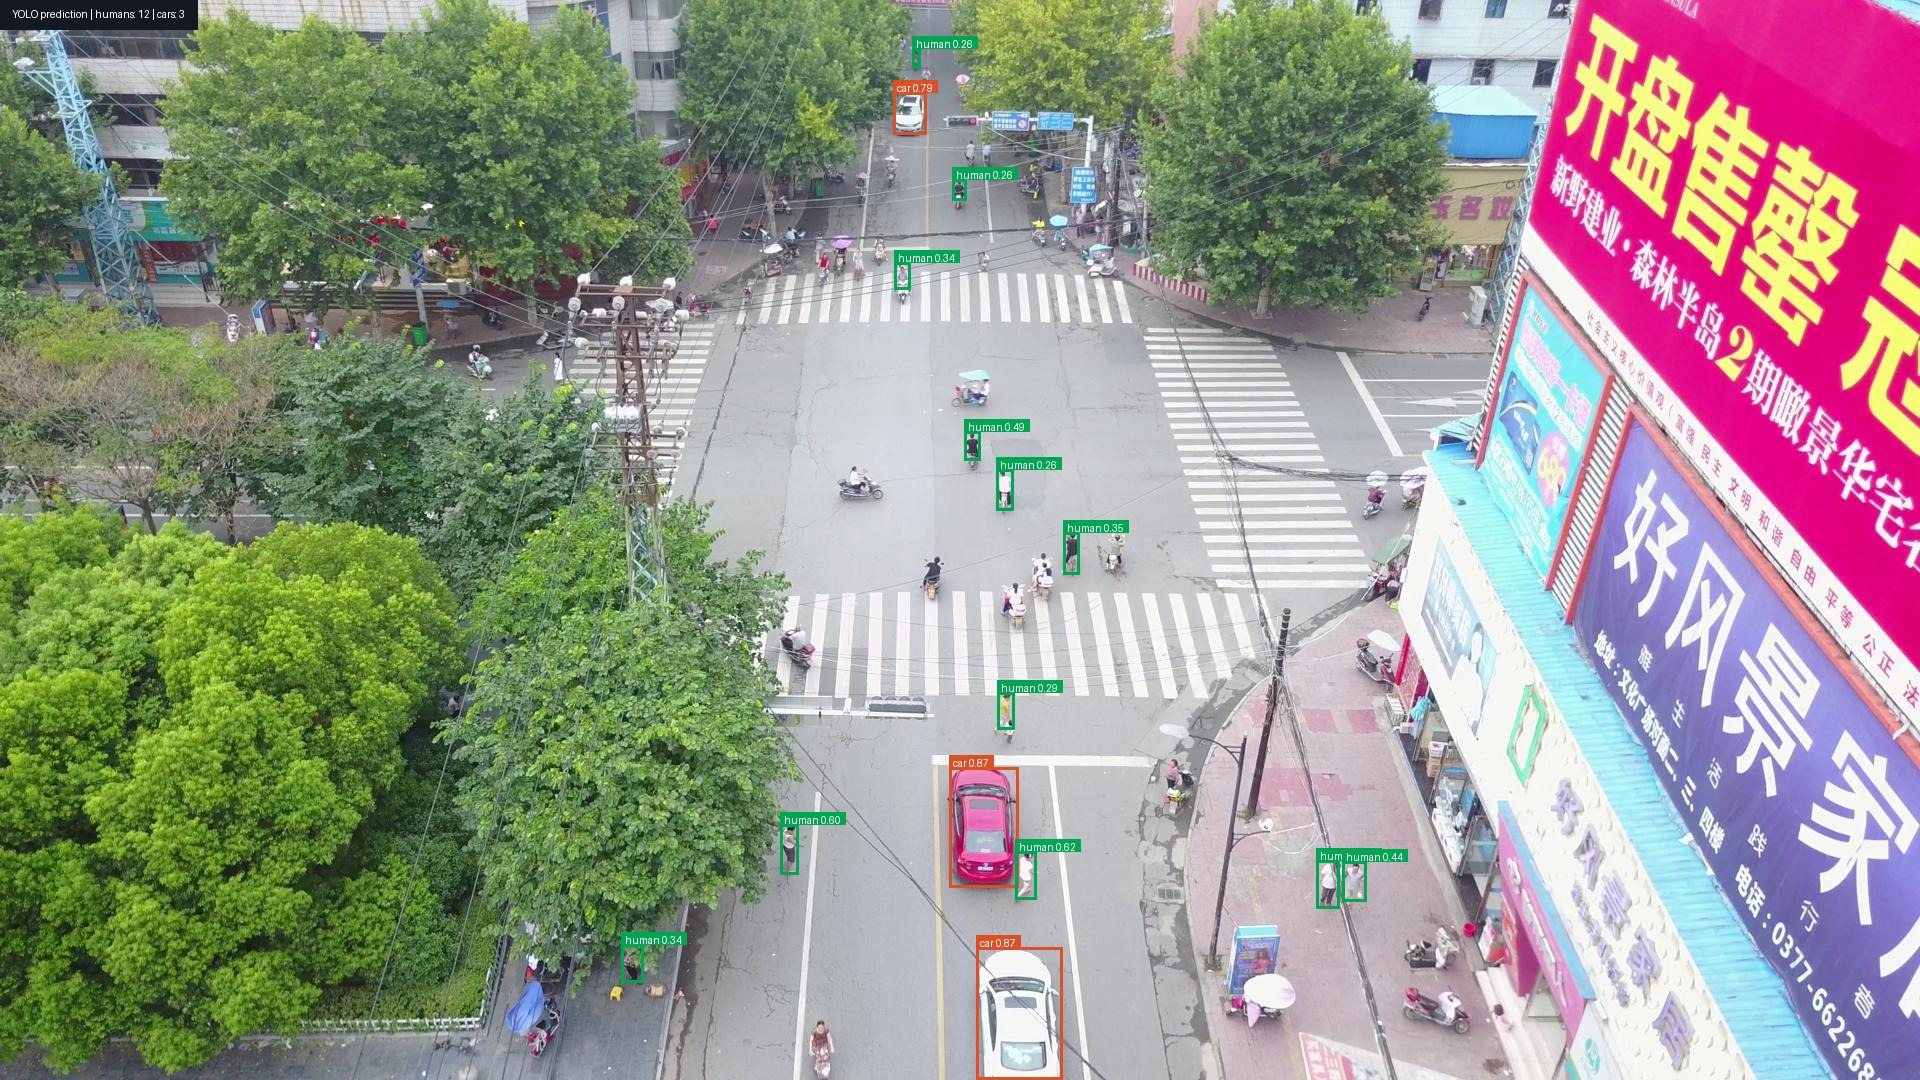

0000001_04527_d_0000008_count.jpg


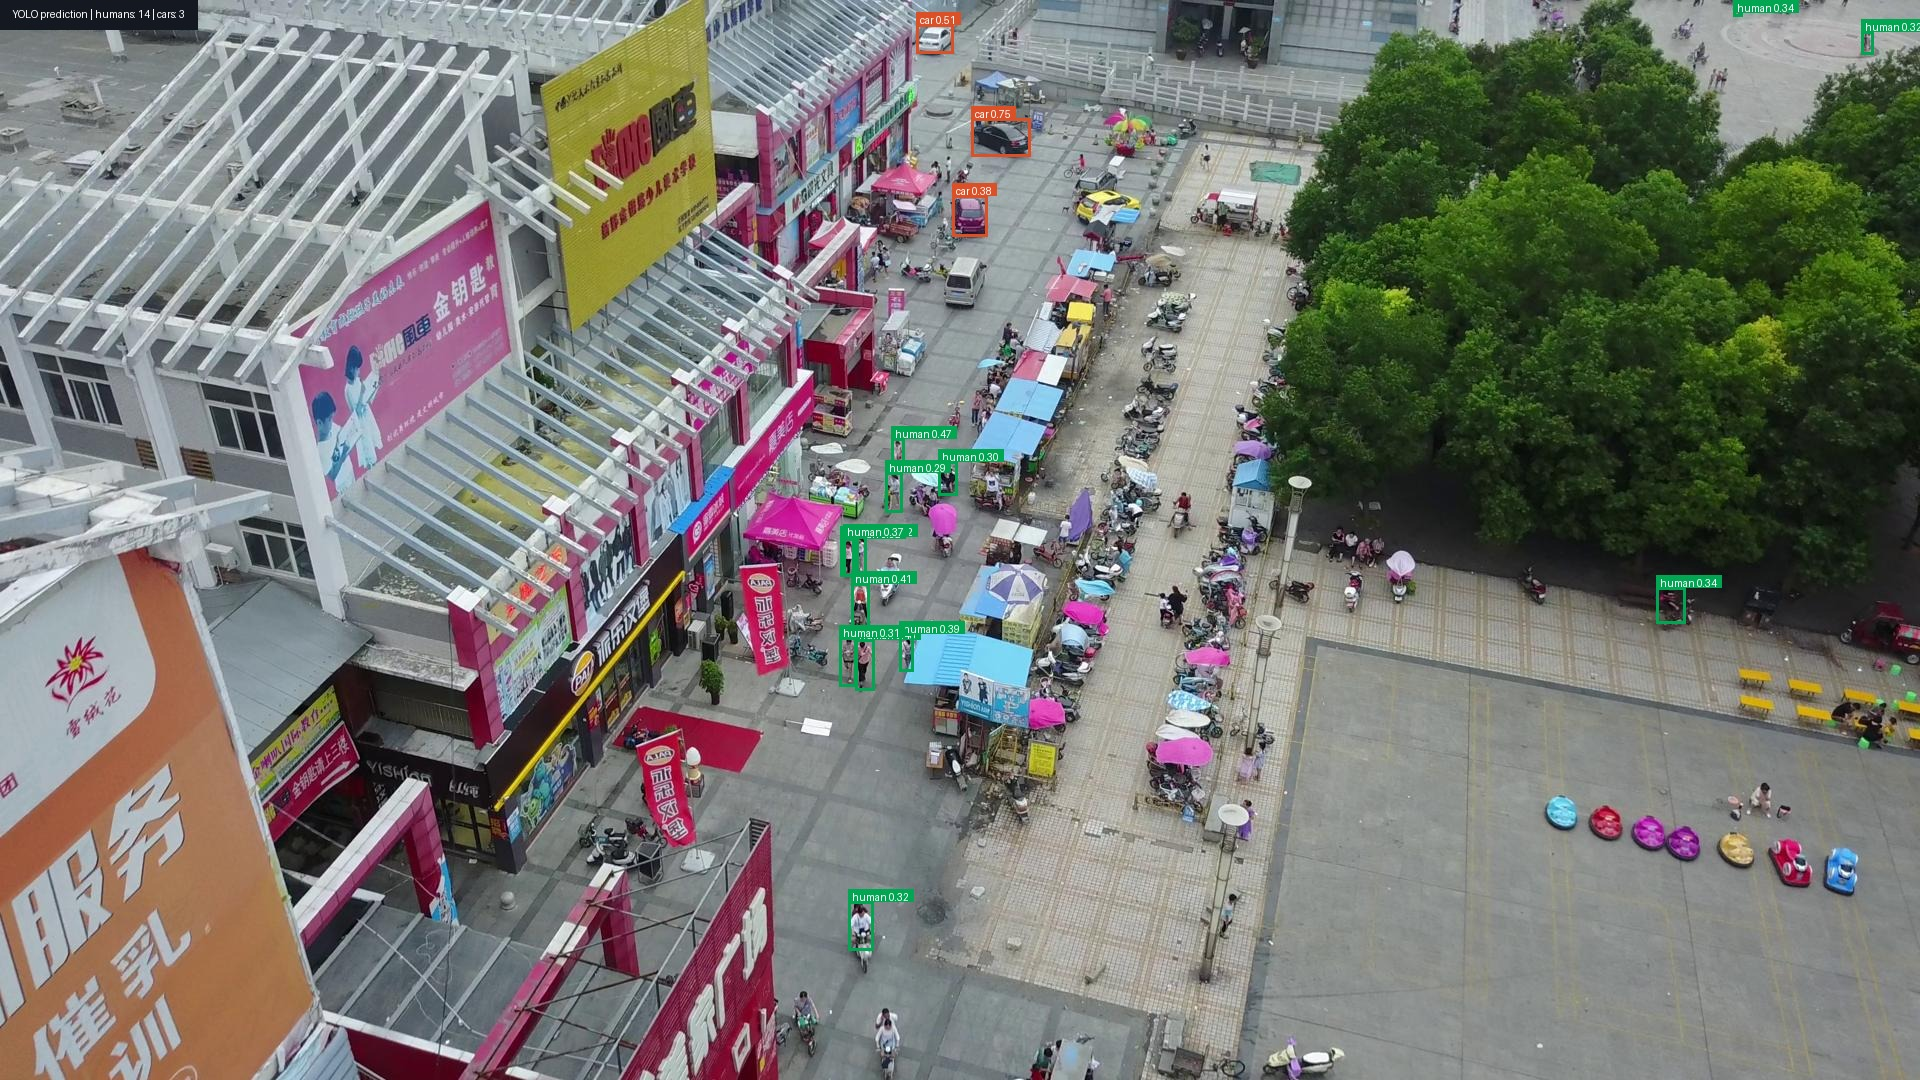

Count summary: /content/drive/MyDrive/visdrone_outputs/predictions/count_summary.csv


In [11]:
from IPython.display import Image, display

prediction_images = sorted((OUTPUT_ROOT / "predictions").glob("*_count.jpg"))[:4]
for image_path in prediction_images:
    print(image_path.name)
    display(Image(filename=str(image_path), width=900))

print("Count summary:", OUTPUT_ROOT / "predictions" / "count_summary.csv")

In [12]:
!python scripts/make_demo_slideshow.py --output "$OUTPUT_ROOT_STR/demo/visdrone_demo.gif"
!cd "$OUTPUT_ROOT_STR" && zip -r visdrone_submission_outputs.zip dataset predictions demo training/*/weights/best.pt
print("Submission zip:", OUTPUT_ROOT / "visdrone_submission_outputs.zip")

Wrote /content/drive/MyDrive/visdrone_outputs/demo/visdrone_demo.gif
  adding: dataset/ (stored 0%)
  adding: dataset/sample_annotations/ (stored 0%)
  adding: dataset/sample_annotations/0000001_03499_d_0000006_targets.jpg (deflated 3%)
  adding: dataset/sample_annotations/0000001_04527_d_0000008_targets.jpg (deflated 3%)
  adding: dataset/sample_annotations/0000001_03999_d_0000007_targets.jpg (deflated 3%)
  adding: dataset/sample_annotations/0000001_02999_d_0000005_targets.jpg (deflated 3%)
  adding: dataset/sample_annotations/0000001_05249_d_0000009_targets.jpg (deflated 3%)
  adding: dataset/sample_annotations/0000001_05499_d_0000010_targets.jpg (deflated 3%)
  adding: dataset/class_distribution.png (deflated 24%)
  adding: dataset/target_distribution.png (deflated 24%)
  adding: dataset/image_size_spread.png (deflated 28%)
  adding: dataset/sample_grid.jpg (deflated 0%)
  adding: dataset/dataset_summary.json (deflated 77%)
  adding: predictions/ (stored 0%)
  adding: predictions/0